Últimas lineas de parte 1 donde guardamos el archivo

In [6]:
df.to_csv("df_final.csv", index=False)

NameError: name 'df' is not defined

#Parte 2

# Preparación de los datos

In [1]:
from google.colab import files
uploaded = files.upload()

Saving df_final.csv to df_final (1).csv


In [2]:
# Extracción del Archivo Tratado

import pandas as pd
df_final = pd.read_csv("df_final.csv")
df_final

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,cuentas_diarias
0,0002-ORFBO,0,0,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,0,1,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,1,1,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,1,1,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,1,0,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,0,0,0,0,0,13,1,No,DSL,...,No,Yes,No,No,One year,0,Mailed check,55.15,742.90,1.838333
7028,9992-RRAMN,1,1,0,1,0,22,1,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,1,Electronic check,85.10,1873.70,2.836667
7029,9992-UJOEL,0,1,0,0,0,2,1,No,DSL,...,No,No,No,No,Month-to-month,1,Mailed check,50.30,92.75,1.676667
7030,9993-LHIEB,0,1,0,1,1,67,1,No,DSL,...,Yes,Yes,No,Yes,Two year,0,Mailed check,67.85,4627.65,2.261667


In [3]:
# Eliminación de Columnas Irrelevantes
df_final.drop('customerID', axis=1, inplace=True)

In [4]:
# Encoding

Encoding = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

# Aplicar get_dummies
df_final_encoded = pd.get_dummies(df_final, columns=Encoding, drop_first=True)

# Verificar
df_final_encoded.head()


,Churn,SeniorCitizen,tenure,Charges_Monthly,Charges_Total,cuentas_diarias,gender_1,Partner_1,Dependents_1,PhoneService_1,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_1,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.266667,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.796667,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [5]:
#Verificación de la Proporción de Cancelación (Churn)
churn_counts = df_final_encoded['Churn'].value_counts()
proporcion = df_final_encoded['Churn'].value_counts(normalize=True) * 100

proporcion

,proportion
Churn,
0,73.421502
1,26.578498


In [6]:
#Balanceo de Clases (opcional)

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# Nuestro x, y
X = df_final_encoded.drop(columns=['Churn'])
y = df_final_encoded['Churn']

# Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)
df_rus = pd.concat([X_rus, y_rus], axis=1)

# Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)
df_ros = pd.concat([X_ros, y_ros], axis=1)

df_rus['Churn'].value_counts()

#Voy a usar undersampling

,count
Churn,
0,1869
1,1869


In [7]:
# Normalización o Estandarización (si es necesario)

from sklearn.preprocessing import StandardScaler
# Escalar para para KNN, SVM, Regresión Logística, Redes Neuronales.
# No necesario para Decision Tree, Random Forest, XGBoost

# Escalamos
numericas = ['SeniorCitizen', 'tenure', 'Charges_Monthly', 'Charges_Total', 'cuentas_diarias']
scaler = StandardScaler()
df_rus_scaled = df_rus.copy()
df_rus_scaled[numericas] = scaler.fit_transform(df_rus_scaled[numericas])

df_rus_scaled.head()




,SeniorCitizen,tenure,Charges_Monthly,Charges_Total,cuentas_diarias,gender_1,Partner_1,Dependents_1,PhoneService_1,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_1,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
2370,-0.482966,0.973179,-0.269164,0.469783,-0.269164,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,0
2285,-0.482966,0.013275,-0.265716,-0.156190,-0.265716,True,True,True,False,True,...,True,False,True,True,False,True,True,False,False,0
5789,2.070538,0.221950,0.891023,0.475254,0.891023,True,True,False,True,False,...,False,False,True,True,False,True,False,True,False,0
1606,-0.482966,-1.071833,-1.634494,-0.910572,-1.634494,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,0
4304,-0.482966,-0.195399,-1.656905,-0.728648,-1.656905,True,True,True,True,False,...,False,True,False,True,False,False,False,False,True,0


#  Correlación y Selección de Variables

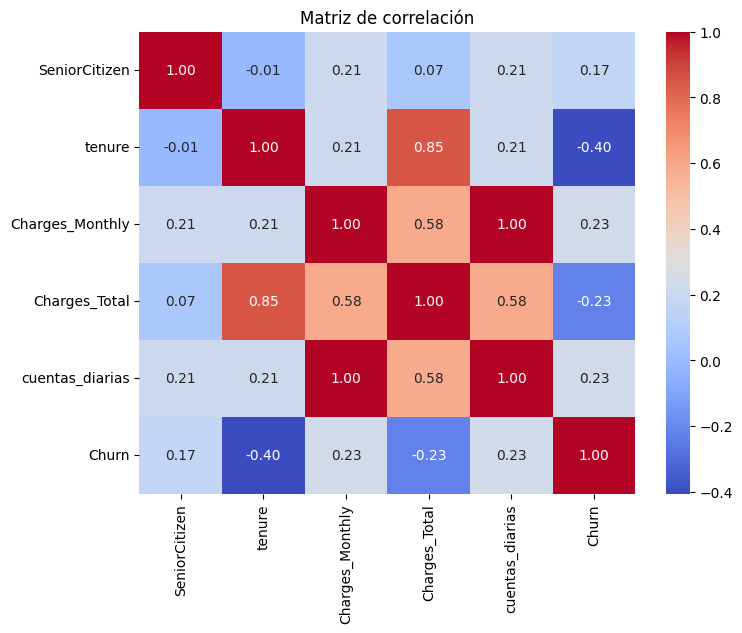

In [8]:
# Analisis de correlación

import matplotlib.pyplot as plt
import seaborn as sns

# Ahora incluimos a Churn
numericas = ['SeniorCitizen', 'tenure', 'Charges_Monthly', 'Charges_Total', 'cuentas_diarias', 'Churn']

# Matriz de correlación
corr_matrix = df_rus_scaled[numericas].corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

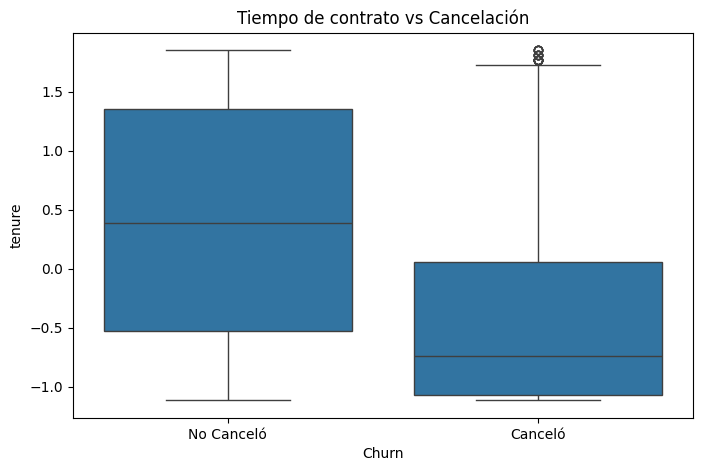

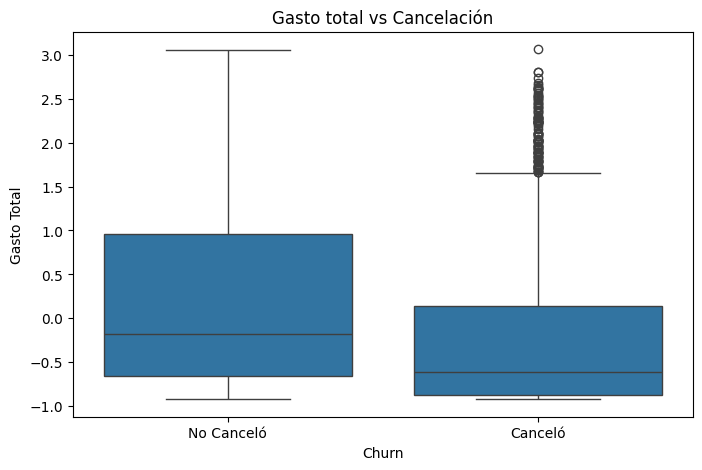

In [9]:
# Análisis Dirigido


# Tiempo de contrato × Cancelación
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df_rus_scaled)
plt.xticks([0,1], ['No Canceló','Canceló'])
plt.title('Tiempo de contrato vs Cancelación')
plt.ylabel('tenure')
plt.show()

# Gasto total × Cancelación
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Charges_Total', data=df_rus_scaled)
plt.xticks([0,1], ['No Canceló','Canceló'])
plt.title('Gasto total vs Cancelación')
plt.ylabel('Gasto Total')
plt.show()

# Modelo Predictivo

In [10]:
#Separacion de datos

from sklearn.model_selection import train_test_split

# Variables predictoras, y
X = df_rus_scaled.drop(columns=['Churn'])
y = df_rus_scaled['Churn']

# 70% entrenamiento, 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print("Proporción Train %:", len(X_train)/len(X)*100)
print("Proporción Test %:", len(X_test)/len(X)*100)

(2616, 31) (1122, 31)
Proporción Train %: 69.98394863563404
Proporción Test %: 30.01605136436597


In [11]:
# Creación de Modelos

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Regresión Logística")
print(classification_report(y_test, y_pred_lr))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_lr))
print("\n")

Regresión Logística
              precision    recall  f1-score   support

           0       0.80      0.71      0.75       561
           1       0.74      0.82      0.77       561

    accuracy                           0.76      1122
   macro avg       0.77      0.76      0.76      1122
weighted avg       0.77      0.76      0.76      1122

Matriz de confusión:
[[396 165]
 [102 459]]




In [12]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print("\n")

Random Forest
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       561
           1       0.75      0.80      0.77       561

    accuracy                           0.77      1122
   macro avg       0.77      0.77      0.77      1122
weighted avg       0.77      0.77      0.77      1122

Matriz de confusión:
[[411 150]
 [112 449]]




In [13]:

# Support Vector Machine
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM")
print(classification_report(y_test, y_pred_svm))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_svm))

SVM
              precision    recall  f1-score   support

           0       0.79      0.70      0.75       561
           1       0.73      0.82      0.77       561

    accuracy                           0.76      1122
   macro avg       0.76      0.76      0.76      1122
weighted avg       0.76      0.76      0.76      1122

Matriz de confusión:
[[395 166]
 [102 459]]


In [14]:
# Evaluación de modelos

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Modelos
modelos = {
    "Regresión Logística": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

# Evaluación de modelos
for nombre, y_pred in modelos.items():
    print(f"{nombre}")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {acc:.2f}")
    print(f"Precisión: {prec:.2f}")
    print(f"Recall: {rec:.2f}")
    print(f"F1-score: {f1:.2f}")
    print("Matriz de confusión:")
    print(cm)
    print("\n")

Regresión Logística
Accuracy: 0.76
Precisión: 0.74
Recall: 0.82
F1-score: 0.77
Matriz de confusión:
[[396 165]
 [102 459]]


Random Forest
Accuracy: 0.77
Precisión: 0.75
Recall: 0.80
F1-score: 0.77
Matriz de confusión:
[[411 150]
 [112 449]]


SVM
Accuracy: 0.76
Precisión: 0.73
Recall: 0.82
F1-score: 0.77
Matriz de confusión:
[[395 166]
 [102 459]]





Análisis de la Importancia de las Variables

Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.



In [15]:
coef = pd.Series(lr.coef_[0], index=X.columns)
coef.sort_values(ascending=False)

,0
Charges_Total,0.719603
InternetService_Fiber optic,0.637319
MultipleLines_No phone service,0.445488
PaperlessBilling_1,0.273720
PaymentMethod_Electronic check,0.198524
StreamingMovies_Yes,0.142745
SeniorCitizen,0.091367
StreamingTV_Yes,0.057596
cuentas_diarias,0.051677
Charges_Monthly,0.051677


Entre las variables que más aumentan la probabilidad de cancelación destacan Charges_Total, InternetService_Fiber optic y MultipleLines_No phone service. Esto sugiere que los clientes con mayores cargos acumulados o con ciertos tipos de servicio de internet presentan mayor tendencia a cancelar.

Por otro lado, variables como tenure, Contract_Two year y Contract_One year presentan coeficientes negativos importantes, lo que indica que los clientes con mayor antigüedad o con contratos de mayor duración tienen menor probabilidad de abandonar el servicio.



Random Forest

Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.



In [16]:
import pandas as pd

importancia = pd.Series(rf.feature_importances_, index=X.columns)
importancia = importancia.sort_values(ascending=False)

print(importancia.head(10))

Charges_Total                     0.154845
tenure                            0.154725
Charges_Monthly                   0.118671
cuentas_diarias                   0.116511
Contract_Two year                 0.057155
InternetService_Fiber optic       0.037833
PaymentMethod_Electronic check    0.031998
Contract_One year                 0.024385
TechSupport_Yes                   0.024313
gender_1                          0.022213
dtype: float64


Las variables con mayor importancia fueron Charges_Total, tenure, Charges_Monthly y cuentas_diarias, lo que indica que los aspectos relacionados con los cargos y la antigüedad del cliente tienen una fuerte influencia en la predicción de cancelación.

También destacan variables como Contract_Two year, InternetService_Fiber optic y PaymentMethod_Electronic check, lo que sugiere que el tipo de contrato, el servicio de internet y el método de pago también influyen en el comportamiento de abandono de los clientes.





SVM

 Las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

In [17]:
svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

coeficientes = pd.Series(svm.coef_[0], index=X.columns)
coeficientes = coeficientes.sort_values(ascending=False)

print(coeficientes)

cuentas_diarias                          0.001414
Charges_Monthly                          0.001414
MultipleLines_No phone service           0.000994
PaperlessBilling_1                       0.000155
SeniorCitizen                            0.000053
PaymentMethod_Electronic check           0.000045
Dependents_1                             0.000037
PaymentMethod_Credit card (automatic)    0.000018
Partner_1                               -0.000002
Charges_Total                           -0.000028
gender_1                                -0.000062
PaymentMethod_Mailed check              -0.000079
tenure                                  -0.000116
MultipleLines_Yes                       -0.000434
DeviceProtection_Yes                    -0.000480
OnlineBackup_Yes                        -0.000566
OnlineSecurity_Yes                      -0.000582
TechSupport_Yes                         -0.000728
StreamingMovies_Yes                     -0.000831
StreamingTV_Yes                         -0.000918


Entre las variables con mayor influencia positiva destacan Charges_Monthly, cuentas_diarias y MultipleLines_No phone service, lo que sugiere que los factores relacionados con los cargos del servicio influyen en la probabilidad de cancelación. Por otro lado, variables como Contract_Two year, Contract_One year y tenure presentan coeficientes negativos más fuertes, indicando que los clientes con contratos de mayor duración o con mayor antigüedad tienen menor probabilidad de cancelar el servicio.

# Informe final



El objetivo de esta segunda etapa del análisis fue desarrollar modelos predictivos que permitieran estimar la probabilidad de cancelación de los clientes de TelecomX. A partir del conjunto de datos previamente limpio y tratado en TelecomX_LATAM_P1, se prepararon las variables necesarias para entrenar distintos modelos de machine learning y analizar qué factores influyen con mayor fuerza en el abandono del servicio.

**Preparación de datos**

Primero se separaron las variables predictoras (X) de la variable objetivo (y), que corresponde a la cancelación del cliente (Churn). Posteriormente, los datos se dividieron en un conjunto de entrenamiento y otro de prueba. El 70% de los datos se utilizó para entrenar los modelos y el 30% restante para evaluarlos. Como resultado, el conjunto de entrenamiento quedó compuesto por 2616 registros y el conjunto de prueba por 1122 registros.

**Modelos**

Para el análisis se aplicaron tres modelos de clasificación: regresión logística, random forest y support vector machine (SVM). Cada modelo permite analizar el problema desde un enfoque diferente y comparar su capacidad para predecir la cancelación de clientes.

La regresión logística se utilizó como modelo base para analizar la relación entre las variables y la probabilidad de churn. Este modelo alcanzó una precisión general cercana al 76%. Al analizar los coeficientes del modelo se observa que variables como Charges_Total e InternetService_Fiber optic aumentan la probabilidad de cancelación, mientras que variables como tenure, Contract_One year y Contract_Two year reducen significativamente ese riesgo. Esto sugiere que la antigüedad del cliente y los contratos de mayor duración influyen en la permanencia.

El modelo random forest, basado en múltiples árboles de decisión, presentó el mejor desempeño general con una precisión cercana al 77%. El análisis de importancia de variables muestra que factores como Charges_Total, tenure, Charges_Monthly y cuentas_diarias son los que más contribuyen a las decisiones del modelo. También destacan variables relacionadas con el tipo de contrato y el servicio de internet, lo que indica que los aspectos de facturación y duración del servicio son clave para explicar la cancelación.

Por su parte, el modelo SVM mostró un desempeño similar, con una precisión cercana al 76%. En este modelo, las variables más relevantes son aquellas que influyen en la frontera de decisión que separa a los clientes que cancelan de los que permanecen. El análisis de los coeficientes muestra que factores como Charges_Monthly y cuentas_diarias se asocian con una mayor probabilidad de cancelación, mientras que variables como Contract_One year y Contract_Two year reducen fuertemente este riesgo.

**Evaluación de los modelos**

Para evaluar el rendimiento se utilizaron métricas como accuracy, precisión, recall y F1-score, además de la matriz de confusión. La regresión logística obtuvo una accuracy de 0.76, con precisión de 0.74, recall de 0.82 y F1-score de 0.77. La matriz de confusión muestra 396 verdaderos negativos y 459 verdaderos positivos, con 165 falsos positivos y 102 falsos negativos.

El modelo random forest presentó una accuracy de 0.77, precisión de 0.75, recall de 0.80 y F1-score de 0.77. En su matriz de confusión se observan 411 verdaderos negativos y 449 verdaderos positivos.

El modelo SVM obtuvo una accuracy de 0.76, precisión de 0.73, recall de 0.82 y F1-score de 0.77. En general, los tres modelos presentan resultados similares, aunque random forest mostró un desempeño ligeramente superior.

**Conclusión**

Los modelos aplicados permitieron identificar patrones relevantes asociados a la cancelación de clientes en TelecomX. Aunque los tres modelos presentan un desempeño similar, random forest mostró el mejor rendimiento general y una buena capacidad para identificar clientes con riesgo de cancelar el servicio. Además, el análisis de variables permitió identificar que factores como la antigüedad del cliente, el tipo de contrato y los cargos del servicio tienen un impacto importante en el comportamiento de cancelación.
